<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [1 - Data Importing and Exploration](#1---data-importing-and-exploration)
    - 1a) Importing
    - 1b) Data Set Dimensions
    - 1c) Missing Values
    - 1d) Redundant Features
    - 1e) Engineered Features
    - 1f) Exploration
    - 1g) Input Feature Data Types
- [2 - Data Preparation](#2---data-preparation)
    - 2a) Null Handling
    - 2b) Duplicate Handling
    - 2c) Discussion
    - 2d) Missing Row Handling
    - 2e) Data Partitioning
    - 2f) Impute Missing Values
    - 2g) Encode the Remaining Categorical Features and Scale Numerical Features
- [3 - Initial Model Training](#3---initial-model-training)
    - 3a) Create Models
    - 3b) Check Predictions
    - 3c) Calculate Metrics
    - 3d) Discussion
- [4 - Tuning Model Hyperparameters](#4---tuning-model-hyperparameters)
    - 4a) Hyperparameter Tuning of Support Vector Classifier
    - 4b) Hyperparameter Tuning of Logistic Regressor
    - 4c) Hyperparameter Tuning of Decision Tree Classifier
- [5 - Model Selection](#5---model-selection)
    - 5a) Algorithm Selection
    - 5b) Check Predictions
    - 5c) Gather Metrics
    - 5d) Discussion

</div>

##### **IMPORTANT**

- Hyperlinks do not work, please use the dropdown buttons for easier navigation if it helps!

---

##### **ORIENTATION**

- This follows COMP4432's week 5-6 assignment using the titanic dataset
- Models Used
    - Support Vector Classifier
    - Linear Regression
    - Decision Tree Regressor
- Encoding Types
    - Onehot

---

##### **SUMMARY**

- Completed

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Arrays and matricies
import numpy as np

# Databasing
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and CV
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, confusion_matrix, classification_report, roc_auc_score

# Encoders/Scalers/Transformers
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Ignore warnings because no...
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 1 - Data Importing and Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

#### 1a) Importing

In [241]:
# Load the seaborn titanic dataset
df = sns.load_dataset('titanic')

# Show an example of the dataset
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---

#### 1b) Data Set Dimensions

In [242]:
# Show quick dimensions
print(df.shape)

# Show more complete description
print(df.info())

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


---

#### 1c) Missing Values

In [243]:
# Obtain raw and pct null count for each column
raw_nulls = df.isnull().sum()
pct_nulls = round(df.isnull().sum() / df.shape[0], 3) * 100

# Combine info into a single easy to read df
full_nulls = pd.concat([raw_nulls, pct_nulls], 
                       axis=1, 
                       keys=['Null Counts', 'Null Pct']
                       )

# Show raw/pct null counts
full_nulls

,Null Counts,Null Pct
survived,0,0.0
pclass,0,0.0
sex,0,0.0
age,177,19.9
sibsp,0,0.0
parch,0,0.0
fare,0,0.0
embarked,2,0.2
class,0,0.0
who,0,0.0


---

#### 1d) Redundant Features

##### 1di) Check 'alive' & 'survived'

In [244]:
# Observe value counts
df.groupby(['alive'])['survived'].value_counts()

alive  survived
no     0           549
yes    1           342
Name: count, dtype: int64

**CONLUSION:** 'alive' & 'survived' are the exact same information!!!

##### 1dii) Check 'pclass' & 'class'

In [245]:
# Observe value counts
df.groupby(['pclass'])['class'].value_counts()

pclass  class 
1       First     216
        Second      0
        Third       0
2       Second    184
        First       0
        Third       0
3       Third     491
        First       0
        Second      0
Name: count, dtype: int64

**CONCLUSION:** 'pclass' & 'class' are the exact same information!!!

##### 1diii) Check 'embarked' & 'embark_town'

In [246]:
# Observe value counts
df.groupby(['embarked'])['embark_town'].value_counts()

embarked  embark_town
C         Cherbourg      168
Q         Queenstown      77
S         Southampton    644
Name: count, dtype: int64

**CONCLUSION:** 'embarked' & 'embark_town' are the exact same information!!!

##### 1div) Check 'adult_male' & 'who'

In [247]:
# Observe value counts
df.groupby(['adult_male'])['who'].value_counts()

adult_male  who  
False       woman    271
            child     83
True        man      537
Name: count, dtype: int64

**CONCLUSION:** 'adult_male' & 'who' are the exact same information *IF* entries that are children are ignored!!!

---

#### 1e) Engineered Features

##### 1ei)

In [248]:
# Recall the features in the df
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Appears that maybe 'adult_male' is related to 'sex' and 'who'

In [249]:
# Check 'sex' & 'adult_male'
df.groupby(['sex'])['adult_male'].value_counts()

sex     adult_male
female  False         314
male    True          537
        False          40
Name: count, dtype: int64

It appears that 'sex' and 'adult_male' are closely related in information, the question is what about the 40 in 'adult_male' are not considered male in 'sex'

In [250]:
# Check the value counts of 'who' after filtering 'sex' == 'male'
df[df['sex'] == 'male']['who'].value_counts()

who
man      537
child     40
Name: count, dtype: int64

In [251]:
# Check distribution of 'child' labels
df[df['who'] == 'child']['sex'].value_counts()

sex
female    43
male      40
Name: count, dtype: int64

In [252]:
# Verify the two groups match:
# Group 1:
    # 'who' == 'child'
    # 'sex' == 'male'
# Group 2:
    # 'sex' == 'male'
    # 'adult_male' == False
group_1 = df[(df['who'] == 'child') & (df['sex'] == 'male')]
group_2 = df[(df['sex'] == 'male') & (df['adult_male'] == False)]

# Check equivalency
group_1.equals(group_2)

True

##### 1eii)

'adult_male' is engineered from 'who' and 'sex' such that:
- 'adult_male' == True
    - 'who' != 'child' &
    - 'sex' == 'male'
- 'adult_male' == False
    - Otherwise

---

#### 1f) Exploration

##### 1fi)

In [253]:
# Observe raw and percentage counts of survival by sex
print(df.groupby(['sex'])['survived'].value_counts())
print(df.groupby(['sex'])['survived'].value_counts(normalize=True))

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64
sex     survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64


More men died on the Titanic both by raw value and percentage of their respective populations

##### 1fii)

In [254]:
# Observe survival by pclass
df.groupby(['pclass'])['survived'].value_counts(normalize=True)

pclass  survived
1       1           0.629630
        0           0.370370
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: proportion, dtype: float64

Passengers of pclass 1 had the highest likelihood of survival whereas pclass 3 had the highest likelihood of dying

##### 1fiii)

<Axes: xlabel='age', ylabel='Count'>

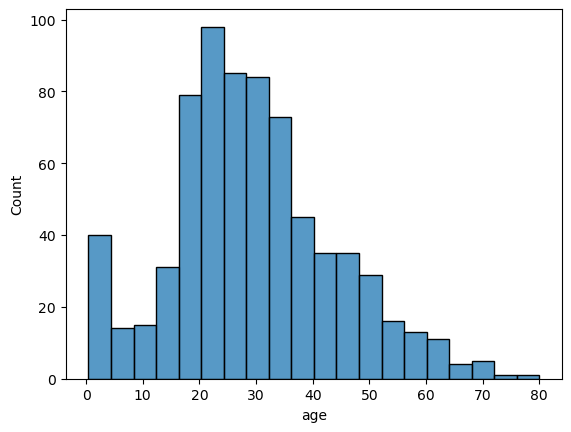

In [255]:
# Plot distribution of non-null age values
sns.histplot(df[df['age'].isnull() == False]['age'])

The distribution of non-null age values are generally positively skewed with the exception of ages <5

##### 1fiv)

In [256]:
# Observe median age of survived and died by pclass
df.groupby(['pclass', 'survived'])['age'].median()

pclass  survived
1       0           45.25
        1           35.00
2       0           30.50
        1           28.00
3       0           25.00
        1           22.00
Name: age, dtype: float64

##### 1fv)

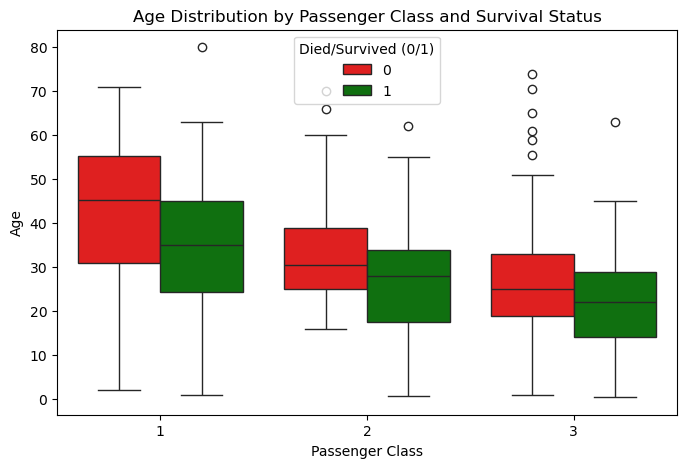

In [257]:
# Setup the plot size
plt.figure(figsize=(8, 5))

# Draw boxplots of age by pclass for survived/died
sns.boxplot(data=df, 
            x='pclass', 
            y='age', 
            hue='survived',
            palette=['red', 'green'])

# Labels
plt.title('Age Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.legend(title='Died/Survived (0/1)')

# Show visualization
plt.show()

##### 1fvi)

- Passengers had a higher likelihood of surviving for any of the following:
    - Is a female
    - Part of the higher pclass (i.e. 1)
    - Was part of the younger age compared to their respective pclass population

---

#### 1g) Input Feature Data Types

##### 1gi)

In [258]:
# Observe dtypes of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


##### 1gii)

- Categorical Features
    - survived
    - pclass
    - sex
    - embarked
    - class
    - who
    - adult_male
    - deck
    - embark_town
    - alive
    - alone
- Numerical Features
    - age
    - sibsp
    - parch
    - fare

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 2 - Data Preparation

- [Back to Table of Contents](#table-of-contents)

</div>

#### 2a) Null Handling

In [259]:
# YAY FUNCTIONS!!!
def remove_features_by_null_pct(df:pd.DataFrame, pct_null_cutoff:float=0.75) -> pd.DataFrame:
    '''
    About
    -----
    - Takes a Pandas DataFrame and removes any feature that has **STRICTLY** more than
      *pct_null_cutoff* amount of nulls within the feature

    Parameters
    ----------
    - df: pd.DataFrame
        - The Pandas DataFrame to filter through
    - pct_null_cutoff: float
        - DEFAULT: 0.75
        - Percentage of nulls that the feature must **STRICTLY** have more than to be removed

    Returns
    -------
    - pd.DataFrame
        - The Pandas DataFrame after features are removed
    '''
    # ===== Calculate Null Percentages ======================================
    null_pcts = df.isnull().mean()

    # ===== Logging Outputs =================================================
    for col_name, pct_null in null_pcts.items():
        if pct_null <= pct_null_cutoff:
            print(f'\033[32mKEEPING {col_name} AT {pct_null:.3f}\033[0m')
        else:
            print(f'\033[31mREMOVING {col_name} AT {pct_null:.3f}\033[0m')

    # ===== Filter and Return DataFrame =====================================
    # Keep columns where null percentage is LESS THAN OR EQUAL TO cutoff
    keep_cols = null_pcts[null_pcts <= pct_null_cutoff].index
    
    return df[keep_cols].copy()

In [260]:
# Remove features > 75% null
df = remove_features_by_null_pct(df)

# Check removal was successful
df.columns

KEEPING survived AT 0.000
KEEPING pclass AT 0.000
KEEPING sex AT 0.000
KEEPING age AT 0.199
KEEPING sibsp AT 0.000
KEEPING parch AT 0.000
KEEPING fare AT 0.000
KEEPING embarked AT 0.002
KEEPING class AT 0.000
KEEPING who AT 0.000
KEEPING adult_male AT 0.000
REMOVING deck AT 0.772
KEEPING embark_town AT 0.002
KEEPING alive AT 0.000
KEEPING alone AT 0.000


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

---

#### 2b) Duplicate Handling

In [262]:
# Drop the directed features (alive, class, embark_town, who, adult_male)
df = df.drop(columns=['alive', 'class', 'embark_town', 'who', 'adult_male'])

# Observe remaining features
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'alone'],
      dtype='object')

---

#### 2c) Discussion

Instructions ask to provide discussion on future modeling efforts if *alive* were included as an input feature, recall that the target feature for prediction is *survived* with 549 labeled 0(dead) and 342 labeled 1(survived).  *alive* has this exact same distribution, only with the respective labels no(dead) and yes(survived).  In other words, this feature should never be used as a training feature because it would be the worst-case scenario of target leakage given that it has the exact answers to who died and who survived in the dataset.

---

#### 2d) Missing Row Handling

In [264]:
# Drop rows with null entries in embarked
df = df.dropna(subset=['embarked'])

# Verify 889 rows remain
df.shape[0] == 889

True

---

#### 2e) Data Partitioning

##### 2ei)

In [266]:
# Do the 80-20 split as instructed
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['survived']),
                                                    df['survived'],
                                                    test_size=0.20,
                                                    random_state=411,
                                                    stratify=df['survived'])

##### 2eii)

In [273]:
# Show target distribution is maintained as instructed
print('\033[35mORIGINAL TARGET DIST:\033[0m\n'
      f'{df['survived'].value_counts(normalize=True)}\n\n'
      '\033[35mTRAIN TARGET DIST:\033[0m\n'
      f'{y_train.value_counts(normalize=True)}\n\n'
      '\033[35mTEST TARGET DIST:\033[0m\n'
      f'{y_test.value_counts(normalize=True)}')

ORIGINAL TARGET DIST:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

TRAIN TARGET DIST:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

TEST TARGET DIST:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


---

#### 2f) Impute Missing Values

In [277]:
# Obtain median ages from the training data
pclass_age_medians = X_train.groupby(['pclass'])['age'].median()

# Fill age nulls in training/test nulls
X_train['age'] = X_train['age'].fillna(X_train['pclass'].map(pclass_age_medians))
X_test['age'] = X_test['age'].fillna(X_test['pclass'].map(pclass_age_medians))

# Verify no age nulls in training/test data
print(X_train['age'].isnull().sum() == 0)
print(X_test['age'].isnull().sum() == 0)

True
True


---

#### 2g) Encode the Remaining Categorical Features and Scale Numerical Features

In [280]:
# Recall columns in the current dataset
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 607 to 62
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    711 non-null    int64  
 1   sex       711 non-null    object 
 2   age       711 non-null    float64
 3   sibsp     711 non-null    int64  
 4   parch     711 non-null    int64  
 5   fare      711 non-null    float64
 6   embarked  711 non-null    object 
 7   alone     711 non-null    bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 45.1+ KB


- Categorical Features
    - pclass
    - sex
    - embarked
    - alone
- Numerical Features
    - age
    - sibsp
    - parch
    - fare

In [281]:
# Define variables for above feature groupings
cat_features = ['pclass', 'sex', 'embarked', 'alone']
num_features = ['age', 'sibsp', 'parch', 'fare']

# Use ColumnTransformer to transform categorical with OneHotEncoder and numerical with StandardScaler
col_transform_onehot = ColumnTransformer(transformers=[
    ('cat_transform', OneHotEncoder(sparse_output=False), cat_features), 
    ('num_transform', StandardScaler(), num_features)],
    remainder='passthrough',
    verbose_feature_names_out=False)

# Fit the data on the training dataset
col_transform_onehot.fit(X_train)

# Transform and rebuild the training dataset
X_train_onehot = col_transform_onehot.transform(X_train)
feature_names = col_transform_onehot.get_feature_names_out()
X_train_onehot = pd.DataFrame(X_train_onehot, columns=feature_names, index=X_train.index)

# Transform and rebuild the testing dataset
X_test_onehot = col_transform_onehot.transform(X_test)
feature_names = col_transform_onehot.get_feature_names_out()
X_test_onehot = pd.DataFrame(X_test_onehot, columns=feature_names, index=X_test.index)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 3 - Initial Model Training

- [Back to Table of Contents](#table-of-contents)

</div>

#### 3a) Create Models

##### 3ai)

In [ ]:
# Create the Support Vector Classifier IAW instructions
svc_onehot = SVC(probability=True, random_state=411)

##### 3aii)

In [286]:
# Create the Logistic Regressor IAW instructions
lr_onehot = LogisticRegression(max_iter=10000, random_state=411)

##### 3aiii)

In [287]:
# Create the Decision Tree Classifier IAW instructions
dtc_onehot = DecisionTreeClassifier(random_state=411)

---

#### 3b) Check Predictions

In [289]:
# Get SVC preds/probs
default_svc_preds = cross_val_predict(svc_onehot, X_train_onehot, y_train, cv=5, method='predict')
default_svc_probs = cross_val_predict(svc_onehot, X_train_onehot, y_train, cv=5, method='predict_proba')

# Get LR preds/probs
default_lr_preds = cross_val_predict(lr_onehot, X_train_onehot, y_train, cv=5, method='predict')
default_lr_probs = cross_val_predict(lr_onehot, X_train_onehot, y_train, cv=5, method='predict_proba')

# Get DTC preds/probs
default_dtc_preds = cross_val_predict(dtc_onehot, X_train_onehot, y_train, cv=5, method='predict')
default_dtc_probs = cross_val_predict(dtc_onehot, X_train_onehot, y_train, cv=5, method='predict_proba')

---

#### 3c) Calculate Metrics

In [327]:
# YAY FUNCTIONS!!!
def show_pred_prob_metrics(model_preds:np.ndarray, model_probs:np.ndarray, true_label:pd.Series, model_name_header:str) -> None:
    """
    About
    -----
    - Displays the confusion matrix, classification report, ROC-AUC score, and probability
      distribution of model_preds and model_probs for easy analysis

    Parameters
    ----------
    - model_preds:np.ndarray
        - Model predictions
    - model_probs:np.ndarray
        - Model probabilities
    - true_label:pd.Series
        - True answers to compare to model predictions
    - model_name_header:str
        - Name to be displayed at the top of the metric outputs

    Returns
    -------
    - None
        - Simply prints out information for analysis
    """
    # Print header for output
    print(f'\033[35m========== {model_name_header} ==========\033[0m')

    # Print confusion matrix
    print('\033[36mCONFUSION MATRIX\033[0m')
    print(confusion_matrix(true_label, model_preds))
    print()

    # Print classification report
    print('\033[36mCLASSIFICATION REPORT:\033[0m')
    print(classification_report(true_label, model_preds))
    print()

    # Print ROC-AUC score
    print('\033[36mROC-AUC SCORE:\033[0m')
    pos_probs = model_probs[:, 1]
    print(roc_auc_score(true_label, pos_probs))
    print()

    # Show probability distribution
    plt.figure(figsize=(6, 5))
    
    prob_df = pd.DataFrame({
        'P_hat': pos_probs,
        'survived': true_label
    })
    
    # Plot histogram
    sns.histplot(
        data=prob_df, 
        x='P_hat', 
        hue='survived',
        edgecolor='black',
        bins=50,
        alpha=0.3
    )
    
    # Helpful labels
    plt.xlabel(r'$P(\hat{y}_i = 1 | \mathbf{x}_i)$')
    plt.ylabel('Count')
    plt.show()

========== DEFAULT SVC ==========
CONFUSION MATRIX
[[393  46]
 [ 71 201]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       439
           1       0.81      0.74      0.77       272

    accuracy                           0.84       711
   macro avg       0.83      0.82      0.82       711
weighted avg       0.83      0.84      0.83       711


ROC-AUC SCORE:
0.8236089709232213



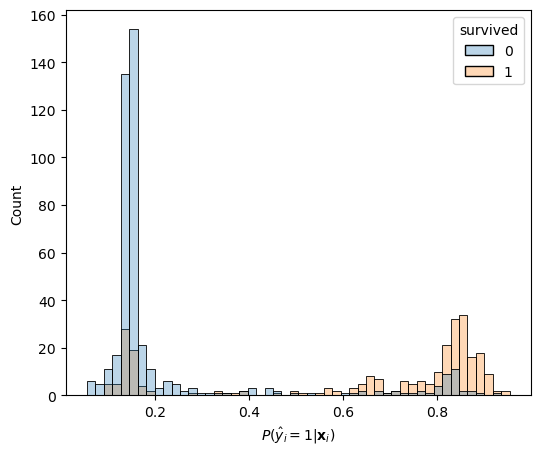

========== DEFAULT LR ==========
CONFUSION MATRIX
[[380  59]
 [ 79 193]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       439
           1       0.77      0.71      0.74       272

    accuracy                           0.81       711
   macro avg       0.80      0.79      0.79       711
weighted avg       0.80      0.81      0.80       711


ROC-AUC SCORE:
0.8571829358166957



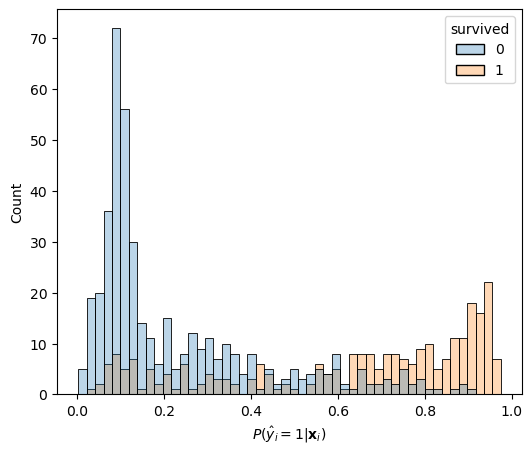

========== DEFAULT DTC ==========
CONFUSION MATRIX
[[356  83]
 [ 74 198]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       439
           1       0.70      0.73      0.72       272

    accuracy                           0.78       711
   macro avg       0.77      0.77      0.77       711
weighted avg       0.78      0.78      0.78       711


ROC-AUC SCORE:
0.7661756331234089



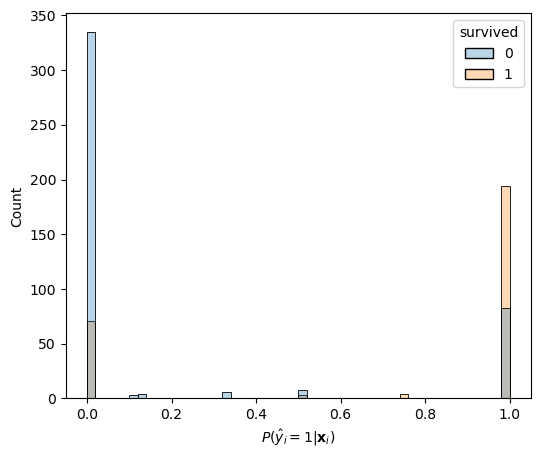

In [329]:
# Show the performances of the 3 default models
show_pred_prob_metrics(default_svc_preds, default_svc_probs, y_train, 'DEFAULT SVC')
show_pred_prob_metrics(default_lr_preds, default_lr_probs, y_train, 'DEFAULT LR')
show_pred_prob_metrics(default_dtc_preds, default_dtc_probs, y_train, 'DEFAULT DTC')

---

#### 3d) Discussion

Between the 3 models, SVC had the best accuracy (i.e. How often a POS/NEG was correctly identified), the best precision for both died/survived (i.e. How correct the predicted label was), the best recall for both died/survived (i.e. How many of the actual died/survived did the model catch), and the 2nd best ROC-AUC score (i.e. How well the model can confidently separate died/survived).  It should be noted that for the predicted probability distribution for the SVC showed a portion of survived as dead and may require further exploration of the data as to why this occurred.  If found, it may bring the score up to a more favorable distribution.

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 4 - Tuning Model Hyperparameters

- [Back to Table of Contents](#table-of-contents)

</div>

#### 4a) Hyperparameter Tuning of Support Vector Classifier

In [352]:
# Define SVC hyperparameters for search
param_grid = {
    'kernel': ['rbf'],
    'C': np.logspace(-3, 3, 25).tolist(),
    'gamma': np.logspace(-4, 1, 20).tolist() + ['scale', 'auto'],
    'class_weight': [None, 'balanced'],
    'shrinking': [True, False],
    'tol': [1e-4, 1e-3]
}

# Setup GridSearchCV IAW instructions
gscv_svc = GridSearchCV(estimator=svc_onehot,
                        param_grid=param_grid,
                        cv=5,
                        verbose=0,
                        n_jobs=1,
                        scoring='accuracy'
)

# Execute GridSearchCV
gscv_svc.fit(X=X_train_onehot,
             y=y_train)

# Print best score and parameters
print(f'\033[35mBest Score:\033[0m\t\t{abs(gscv_svc.best_score_):.4f}\n'
      f'\033[35mBest Hyperparameters:\033[0m\t{gscv_svc.best_params_}')

Best Score:		0.8368
Best Hyperparameters:	{'C': 5.623413251903491, 'class_weight': None, 'gamma': 0.04281332398719392, 'kernel': 'rbf', 'shrinking': True, 'tol': 0.0001}


---

#### 4b) Hyperparameter Tuning of Logistic Regressor

In [353]:
# Define LR hyperparameters for search
param_grid = [
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga', 'liblinear'],
        'C': np.logspace(-4, 4, 30).tolist(),
        'fit_intercept': [True, False],
        'class_weight': [None, 'balanced'],
        'max_iter': [10000]
    },
    {
        'penalty': ['l1'],
        'solver': ['saga', 'liblinear'],
        'C': np.logspace(-4, 4, 30).tolist(),
        'fit_intercept': [True, False],
        'class_weight': [None, 'balanced'],
        'max_iter': [10000]
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': np.logspace(-3, 3, 20).tolist(),
        'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
        'fit_intercept': [True, False],
        'class_weight': [None, 'balanced'],
        'max_iter': [10000]
    },
    {
        'penalty': [None],
        'solver': ['lbfgs', 'saga'],
        'fit_intercept': [True, False],
        'class_weight': [None, 'balanced'],
        'max_iter': [10000]
    }
]

# Setup GridSearchCV IAW instructions
gscv_lr = GridSearchCV(estimator=lr_onehot,
                       param_grid=param_grid,
                       cv=5,
                       verbose=0,
                       n_jobs=1,
                       scoring='accuracy')

# Execute GridSearchCV
gscv_lr.fit(X=X_train_onehot, y=y_train)

# Print best score and parameters
print(f'\033[35mBest Score:\033[0m\t\t{gscv_lr.best_score_:.4f}\n'
      f'\033[35mBest Hyperparameters:\033[0m\t{gscv_lr.best_params_}')

Best Score:		0.8073
Best Hyperparameters:	{'C': 2.592943797404667, 'class_weight': None, 'fit_intercept': True, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}


---

#### 4c) Hyperparameter Tuning of Decision Tree Classifier

In [351]:
# Define DTC hyperparameters for search
param_grid = {
    'max_depth': [None, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10, 15, 20]
}

# Setup GridSearchCV IAW instructions
gscv_dtc = GridSearchCV(estimator=dtc_onehot,
                        param_grid=param_grid,
                        cv=5,
                        verbose=0,
                        n_jobs=1,
                        scoring='accuracy')

# Execute GridSearchCV
gscv_dtc.fit(X=X_train_onehot, y=y_train)

# Print best score and parameters
print(f'\033[35mBest Score:\033[0m\t\t{gscv_dtc.best_score_:.4f}\n'
      f'\033[35mBest Hyperparameters:\033[0m\t{gscv_dtc.best_params_}')

Best Score:		0.8199
Best Hyperparameters:	{'max_depth': 3, 'min_samples_leaf': 6}


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 5 - Model Selection

- [Back to Table of Contents](#table-of-contents)

</div>

#### 5a) Algorithm Selection

Based on optimized accuracy, the Support Vector Classifier should be selected with the best accuracy at 83.68% using the hyperparameters C=5.623413251903491, class_weight=None, gamma=0.04281332398719392, kernel=rbf, shrinking=True, tol=0.0001.

---

#### 5b) Check Predictions

In [354]:
# Get SVC preds/probs
tuned_svc_preds = cross_val_predict(gscv_svc.best_estimator_, X_train_onehot, y_train, cv=5, method='predict')
tuned_svc_probs = cross_val_predict(gscv_svc.best_estimator_, X_train_onehot, y_train, cv=5, method='predict_proba')

# Get LR preds/probs
tuned_lr_preds = cross_val_predict(gscv_lr.best_estimator_, X_train_onehot, y_train, cv=5, method='predict')
tuned_lr_probs = cross_val_predict(gscv_lr.best_estimator_, X_train_onehot, y_train, cv=5, method='predict_proba')

# Get DTC preds/probs
tuned_dtc_preds = cross_val_predict(gscv_dtc.best_estimator_, X_train_onehot, y_train, cv=5, method='predict')
tuned_dtc_probs = cross_val_predict(gscv_dtc.best_estimator_, X_train_onehot, y_train, cv=5, method='predict_proba')


---

#### 5c) Gather Metrics

========== TUNED SVC ==========
CONFUSION MATRIX
[[396  43]
 [ 73 199]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       439
           1       0.82      0.73      0.77       272

    accuracy                           0.84       711
   macro avg       0.83      0.82      0.82       711
weighted avg       0.84      0.84      0.83       711


ROC-AUC SCORE:
0.8257612555272679



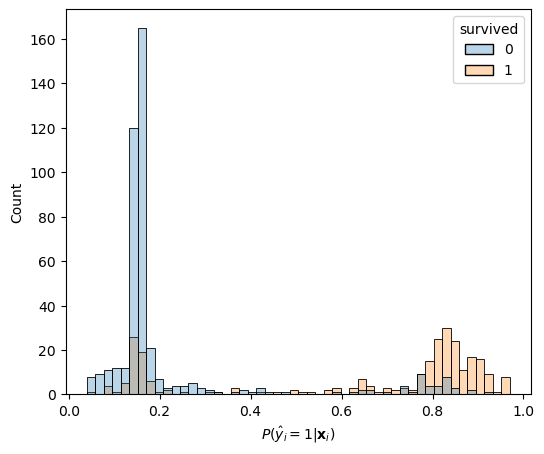

========== TUNED LR ==========
CONFUSION MATRIX
[[381  58]
 [ 79 193]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       439
           1       0.77      0.71      0.74       272

    accuracy                           0.81       711
   macro avg       0.80      0.79      0.79       711
weighted avg       0.81      0.81      0.81       711


ROC-AUC SCORE:
0.8570238174996649



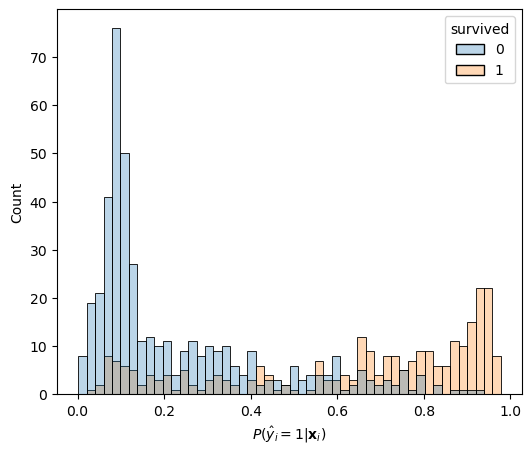

========== TUNED DTC ==========
CONFUSION MATRIX
[[392  47]
 [ 81 191]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       439
           1       0.80      0.70      0.75       272

    accuracy                           0.82       711
   macro avg       0.82      0.80      0.80       711
weighted avg       0.82      0.82      0.82       711


ROC-AUC SCORE:
0.8486868551520836



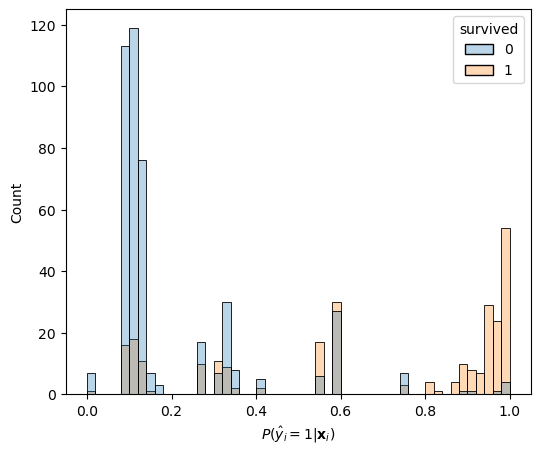

In [355]:
# Show the performances of the 3 tuned models
show_pred_prob_metrics(tuned_svc_preds, tuned_svc_probs, y_train, 'TUNED SVC')
show_pred_prob_metrics(tuned_lr_preds, tuned_lr_probs, y_train, 'TUNED LR')
show_pred_prob_metrics(tuned_dtc_preds, tuned_dtc_probs, y_train, 'TUNED DTC')

---

#### 5d) Discussion

- Default to Tuned Model Comparisons
    - OVERALL
        - FOCUSED METRIC (ACCURACY)
            - No change from SVC and LR, but increase in DTC; however, SVC still has the best performance at ~84%
        - CONFUSION MATRIX
            - SVC and LR had minimal changes where DTC had the best increase in performance
        - CLASSIFICATION REPORT
            - SVC and LR had minimal changes where DTC had the best increase in performance
        - ROC-AUC SCORE
            - LR decreased slightly, SVC increased slightly, and DTC had a good increase in score
        - PREDICTION PROBABILITY DISTRIBUTION
            - Visually appeared to benefit SVC and DTC, but not LR
    - SVC
        - CONFUSION MATRIX
            - 3 more TP, 2 more FP, 3 less FN, 2 less TN
            - Can arguably not have changed much in performance depending on the holistic outlook of the confusion matrix
        - CLASSIFICATION REPORT
            - Similar to above, the performance doesn't appear to have moved much from the default version
            - 0//precision:-0.01
            - 0//recall:+-0.00
            - 0//f1-score:+-0.00
            - 1//precision:+0.01
            - 1//recall:-0.01
            - 1//f1-score:+-0.00
            - accuracy:+-0.00
        - ROC-AUC SCORE
            - Slight increase of ~0.002
        - PREDICTION PROBABILITY DISTRIBUTION
            - The survived in the left side appears to slightly shift towards the right, so the tuned version may have a slightly better time distinguishing the two (Though very small)
    - LR
        - CONFUSION MATRIX
            - 1 more TP, 1 less FN
            - Can arguably not have changed much in performance depending on the holistic outlook of the confusion matrix
        - CLASSIFICATION REPORT
            - All rounded metrics are the same, so aruguably no change
            - 0//precision:+-0.00
            - 0//recall:+-0.00
            - 0//f1-score:+-0.00
            - 1//precision:+-0.00
            - 1//recall:+-0.00
            - 1//f1-score:+-0.00
            - accuracy:+-0.00
        - ROC-AUC SCORE
            - Slight decrease of ~0.0002
        - PREDICTION PROBABILITY DISTRIBUTION
            - Survived distribution appear to make a more "U" shape likely showing that the differentiation became worse after tuning
    - DTC
        - CONFUSION MATRIX
            - 36 more TP, 7 more FP, 36 less FN, 7 less TN
            - Fairly good increase in model performance to the tuned version
        - CLASSIFICATION REPORT
            - Almost all metrics increased in values with precision of died remained the same and recall of survived decreased by 0.03
            - 0//precision:+-0.00
            - 0//recall:+0.08
            - 0//f1-score:+0.04
            - 1//precision:+0.10
            - 1//recall:-0.03
            - 1//f1-score:+0.03
            - accuracy:+0.04
        - ROC-AUC SCORE
            - Increase of ~0.08
        - PREDICTION PROBABILITY DISTRIBUTION
            - Much better distribution of predictions where instead of primarily being a T/F prediction, became more distributed across predictions

- Final Verdict (Should 5a be selected)
    - Based off the accuracy metric, the tuned SVC as is mentioned in 5a should still be used.  Though the accuracy has no change from the classification report, the ROC-AUC had a slight increase so the model should have an ever so slightly better time in differentiating died/survived